# Accident Severity Detection
This project predicts road traffic accident severity using supervised machine learning techniques. Historical accident data was preprocessed and used to train multiple models, with Random Forest achieving the best performance. The system demonstrates how machine learning can support road safety analysis and decision-making.

## Import Libraries

In [32]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## Load Dataset

In [33]:
df = pd.read_csv("Addis_Ababa_city_RTA.csv")
df.head()

,Time,Day_of_week,Age_band_of_driver,Drivers_gender,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Number_of_casualties,Vehicle_movement,Casualty_class,Casualty_gender,Age_band_of_casualty,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,2,Going straight,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,2,Going straight,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,2,Going straight,Driver or rider,Male,31-50,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,2,Going straight,Pedestrian,Female,18-30,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,2,Going straight,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [34]:
df.shape

(13063, 31)

## Understand Dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13063 entries, 0 to 13062
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         13063 non-null  object
 1   Day_of_week                  13063 non-null  object
 2   Age_band_of_driver           13063 non-null  object
 3   Drivers_gender               13063 non-null  object
 4   Educational_level            12297 non-null  object
 5   Vehicle_driver_relation      12464 non-null  object
 6   Driving_experience           12187 non-null  object
 7   Type_of_vehicle              12096 non-null  object
 8   Owner_of_vehicle             12555 non-null  object
 9   Service_year_of_vehicle      9073 non-null   object
 10  Defect_of_vehicle            8496 non-null   object
 11  Area_accident_occured        12823 non-null  object
 12  Lanes_or_Medians             12586 non-null  object
 13  Road_allignment              12

In [8]:
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Drivers_gender                    0
Educational_level               766
Vehicle_driver_relation         599
Driving_experience              876
Type_of_vehicle                 967
Owner_of_vehicle                508
Service_year_of_vehicle        3990
Defect_of_vehicle              4567
Area_accident_occured           240
Lanes_or_Medians                477
Road_allignment                 144
Types_of_Junction                 0
Road_surface_type                 0
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Casualty_gender                   0
Age_band_of_casualty              0
Work_of_casuality              3382
Fitness_of_casuality        

In [9]:
df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Drivers_gender',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Casualty_gender', 'Age_band_of_casualty', 'Work_of_casuality',
       'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident',
       'Accident_severity'],
      dtype='object')

## Select Relevant Column

In [10]:
features = [
    "Weather_conditions",
    "Road_surface_conditions",
    "Light_conditions",
    "Type_of_collision",
    "Time",
    "Type_of_vehicle"
]

target = "Accident_severity"

df = df[features + [target]]
df.head()

,Weather_conditions,Road_surface_conditions,Light_conditions,Type_of_collision,Time,Type_of_vehicle,Accident_severity
0,Normal,Dry,Daylight,Collision with roadside-parked vehicles,17:02:00,Automobile,Slight Injury
1,Normal,Dry,Daylight,Vehicle with vehicle collision,17:02:00,Public (> 45 seats),Slight Injury
2,Normal,Dry,Daylight,Collision with roadside objects,17:02:00,Lorry (41?100Q),Serious Injury
3,Normal,Dry,Darkness - lights lit,Vehicle with vehicle collision,1:06:00,Public (> 45 seats),Slight Injury
4,Normal,Dry,Darkness - lights lit,Vehicle with vehicle collision,1:06:00,NaN,Slight Injury


## Handle Missing Value

In [11]:
for col in df.columns:
    df[col] = df[col].fillna(df[col].mode()[0])

## Encode Categorical Data

In [12]:
encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Weather_conditions,Road_surface_conditions,Light_conditions,Type_of_collision,Time,Type_of_vehicle,Accident_severity
0,2,0,3,3,422,0,2
1,2,0,3,9,422,11,2
2,2,0,3,2,422,5,1
3,2,0,0,9,596,11,2
4,2,0,0,9,596,0,2


## Train-Test Split

In [13]:
X = df.drop("Accident_severity", axis=1)
y = df["Accident_severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Train Logistic Regression

In [15]:
lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [16]:
print("Logistic Regression (Scaled)")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression (Scaled)
Accuracy: 0.4351320321469575
              precision    recall  f1-score   support

           0       0.03      0.37      0.06        62
           1       0.16      0.28      0.20       395
           2       0.85      0.47      0.60      2156

    accuracy                           0.44      2613
   macro avg       0.35      0.37      0.29      2613
weighted avg       0.72      0.44      0.53      2613



## Train Decision Tree

In [17]:
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [18]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred, zero_division=0))


Decision Tree
Accuracy: 0.7034060466896288
              precision    recall  f1-score   support

           0       0.08      0.15      0.10        62
           1       0.25      0.31      0.28       395
           2       0.85      0.79      0.82      2156

    accuracy                           0.70      2613
   macro avg       0.39      0.42      0.40      2613
weighted avg       0.74      0.70      0.72      2613



## Train Random Forest

In [19]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [20]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, zero_division=0))


Random Forest
Accuracy: 0.746268656716418
              precision    recall  f1-score   support

           0       0.08      0.10      0.09        62
           1       0.26      0.21      0.23       395
           2       0.84      0.86      0.85      2156

    accuracy                           0.75      2613
   macro avg       0.39      0.39      0.39      2613
weighted avg       0.73      0.75      0.74      2613



## Model Evaluation

In [21]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)



Logistic Regression
Accuracy: 0.4351320321469575
              precision    recall  f1-score   support

           0       0.03      0.37      0.06        62
           1       0.16      0.28      0.20       395
           2       0.85      0.47      0.60      2156

    accuracy                           0.44      2613
   macro avg       0.35      0.37      0.29      2613
weighted avg       0.72      0.44      0.53      2613


Decision Tree
Accuracy: 0.7034060466896288
              precision    recall  f1-score   support

           0       0.08      0.15      0.10        62
           1       0.25      0.31      0.28       395
           2       0.85      0.79      0.82      2156

    accuracy                           0.70      2613
   macro avg       0.39      0.42      0.40      2613
weighted avg       0.74      0.70      0.72      2613


Random Forest
Accuracy: 0.746268656716418
              precision    recall  f1-score   support

           0       0.08      0.10      0.09   

In [22]:
cm = confusion_matrix(y_test, rf_pred)

## Confusion Matrix

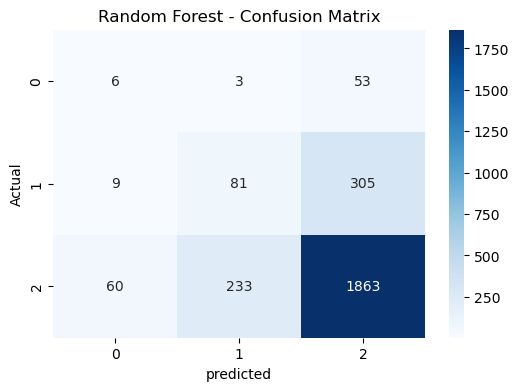

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

In [24]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

Time                       0.679431
Type_of_vehicle            0.161063
Type_of_collision          0.058308
Light_conditions           0.037703
Weather_conditions         0.037234
Road_surface_conditions    0.026260
dtype: float64

## Plot Feature Importance

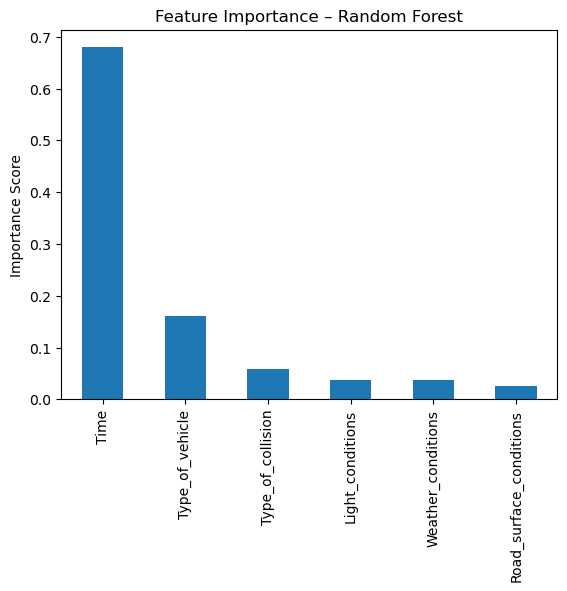

In [25]:
feature_importance.plot(kind="bar")
plt.title("Feature Importance – Random Forest")
plt.ylabel("Importance Score")
plt.show()

## Demo Prediction

In [26]:
sample = X_test.iloc[[0]]
prediction = rf.predict(sample)

prediction

array([2])

## Working Directory

In [27]:
import os
os.getcwd()

'C:\\Users\\HP\\Accident Severity Prediction'

In [28]:
os.listdir()

['.ipynb_checkpoints',
 'accident_severity_model.pkl',
 'Addis_Ababa_city_RTA.csv',
 'Data.ipynb']

## Save Model

In [29]:
joblib.dump(rf, "accident_severity_model.pkl")
print("Model saved successfully")

Model saved successfully


In [30]:
os.listdir()

['.ipynb_checkpoints',
 'accident_severity_model.pkl',
 'Addis_Ababa_city_RTA.csv',
 'Data.ipynb']

In [31]:
model = joblib.load("accident_severity_model.pkl")
print("Model loaded successfully")

Model loaded successfully
